In [94]:
#!/usr/bin/env python3
"""Datathon 2026 · Fashion E-commerce Vietnam

Fixes applied vs previous version:
  3a  — Fix NaN annotation: dùng 2013 làm base year (2012 không có promo)
        Reframe narrative: "locked at ~40%" thay vì "increasing trend"


Chạy: python charts_promotion_fixed.py
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')

DATA_DIR   = '.'
OUTPUT_DIR = 'charts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Seaborn base theme ─────────────────────────────────────────
sns.set_theme(style='whitegrid', font='DejaVu Sans')
sns.set_context('notebook', font_scale=1.05)

# ── Palette: Vàng / Xanh nước biển / Đỏ ──────────────────────
BLUE    = '#1A3D6E'
BLUE_M  = '#2E6DB4'
BLUE_L  = '#A8C8EC'
YELLOW  = '#D4940A'
YELLOW_L= '#F5D080'
RED     = '#B22222'
RED_L   = '#E8897F'
GRAY    = '#555555'
GRAY_L  = '#E8E8E8'
CAT_PALETTE = [BLUE_M, YELLOW, RED, '#5B8DB8', '#C47A2A', '#7B3B3B']

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlepad':    12,
    'axes.labelsize':   11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.22,
    'grid.color':       '#BBBBBB',
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

def fmt_pct(x, _): return f'{x:.0f}%'
def fmt_M(x, _):
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    if abs(x) >= 1e3: return f'{x/1e3:.0f}K'
    return f'{x:.0f}'


# ══════════════════════════════════════════════════════════════
# LOAD & PREPARE DATA
# ══════════════════════════════════════════════════════════════
print('Loading data...')

orders      = pd.read_csv(f'{DATA_DIR}/orders.csv',      parse_dates=['order_date'])
order_items = pd.read_csv(f'{DATA_DIR}/order_items.csv')
products    = pd.read_csv(f'{DATA_DIR}/products.csv')
promotions  = pd.read_csv(f'{DATA_DIR}/promotions.csv',  parse_dates=['start_date','end_date'])
returns_df  = pd.read_csv(f'{DATA_DIR}/returns.csv',     parse_dates=['return_date'])
reviews_df  = pd.read_csv(f'{DATA_DIR}/reviews.csv',     parse_dates=['review_date'])
sales       = pd.read_csv(f'{DATA_DIR}/sales.csv',       parse_dates=['Date'])
sales       = sales.sort_values('Date').reset_index(drop=True)

# Base transaction table
base = (
    order_items
    .merge(orders[['order_id','order_date','order_status','customer_id']], on='order_id')
    .merge(products[['product_id','cogs','price','category','segment']], on='product_id')
)
base = base[base['order_status'] != 'cancelled'].copy()
base['order_date']    = pd.to_datetime(base['order_date'])
base['year']          = base['order_date'].dt.year
base['revenue_line']  = base['unit_price'] * base['quantity']
base['cogs_line']     = base['cogs']       * base['quantity']
base['gross_profit']  = base['revenue_line'] - base['cogs_line'] - base['discount_amount']
base['margin_rate']   = np.where(
    base['revenue_line'] > 0,
    base['gross_profit'] / base['revenue_line'],
    np.nan,
)
base['has_promo']    = base['discount_amount'] > 0
base['list_revenue'] = base['price'] * base['quantity']
base['discount_rate']= np.where(
    base['list_revenue'] > 0,
    1 - base['revenue_line'] / base['list_revenue'],
    np.nan,
)

print(f'  Base table: {len(base):,} rows | {base["year"].min()}–{base["year"].max()}')
print(f'  Promo rate overall: {base["has_promo"].mean():.1%}\n')


# ══════════════════════════════════════════════════════════════
# CHART 3A — Promotion Penetration & Margin Erosion
# FIX: dùng 2013 làm base year (2012 = 0% promo → margin_gap NaN)
# FIX: reframe annotation "locked ~40%" thay vì "trend tăng"
# ══════════════════════════════════════════════════════════════
def chart_3a():
    print('Building Chart 3a...')
    def safe_margin(g, mask):
        rev = g.loc[mask, 'revenue_line'].sum()
        prof = g.loc[mask, 'gross_profit'].sum()
        return (prof / rev)*100 if rev > 0 else np.nan
    def year_agg(g):
        promo  = g['has_promo']
        margin = g['margin_rate']
        return pd.Series({
            'promo_penetration': promo.mean() * 100,
            'margin_promo':      safe_margin(g, promo),
            'margin_no_promo':   safe_margin(g, ~promo)
        })

    yr = base.groupby('year').apply(year_agg).reset_index()
    yr['margin_gap'] = yr['margin_no_promo'] - yr['margin_promo']

    # FIX: tính gap từ 2013 (năm đầu tiên có promo), không dùng 2012
    yr_with_promo = yr[yr['promo_penetration'] > 0].reset_index(drop=True)
    base_year     = int(yr_with_promo['year'].iloc[0])   # 2013
    last_year     = int(yr_with_promo['year'].iloc[-1])  # 2022
    gap_base      = yr_with_promo['margin_gap'].iloc[0]
    gap_last      = yr_with_promo['margin_gap'].iloc[-1]

    delta_valid = (
        pd.notna(gap_base) and pd.notna(gap_last)
        and gap_base != 0
    )
    delta_text = (
        f'Gap change: {gap_last - gap_base:+.1f}pp\n(vs {base_year})'
        if delta_valid else
        f'Gap {last_year}: {gap_last:.1f}pp'
    )

    fig, ax1 = plt.subplots(figsize=(13, 6))
    ax2 = ax1.twinx()

    # Shaded area giữa hai đường margin
    ax2.fill_between(yr['year'], yr['margin_promo'], yr['margin_no_promo'],
                     alpha=0.10, color=BLUE_M)

    # Margin lines (right axis)
    l1, = ax2.plot(yr['year'], yr['margin_no_promo'],
                   color=BLUE_M, lw=2.5, marker='o', ms=7, zorder=4,
                   label='Margin — no promo')
    l2, = ax2.plot(yr['year'], yr['margin_promo'],
                   color=RED, lw=2.5, marker='s', ms=7, zorder=4,
                   label='Margin — with promo')

    # Annotate year 2021 — năm margin promo gần 0% nhất
    yr_2021 = yr[yr['year'] == 2021]
    if len(yr_2021):
        mp21 = float(yr_2021['margin_promo'].values[0])
        if pd.notna(mp21):
            ax2.annotate(
                f'2021\nMargin promo ≈ {mp21:.1f}%',
                xy=(2021, mp21), xytext=(2019.3, mp21 + 5),
                fontsize=8.5, color=RED, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=RED, lw=1.4),
            )

    ax2.set_ylabel('Gross margin rate (%)', color=GRAY, labelpad=10)
    ax2.tick_params(axis='y', labelcolor=GRAY)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
    ax2.spines['right'].set_visible(True)
    ax2.spines['right'].set_color('#DDDDDD')
    ax2.spines['top'].set_visible(False)

    # Promo penetration (left axis)
    l3, = ax1.plot(yr['year'], yr['promo_penetration'],
                   color=YELLOW, lw=2.5, ls='--', marker='D', ms=7, zorder=4,
                   label='Promo penetration')
    ax1.set_ylabel('Promo penetration (%)', color=YELLOW, labelpad=10)
    ax1.tick_params(axis='y', labelcolor=YELLOW)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
    ax1.set_xticks(yr['year'])
    ax1.set_xlabel('')

    # FIX: annotation dùng base_year thay vì yr.iloc[0] (tránh NaN 2012)
    mid_y = float((yr['margin_promo'].iloc[-1] + yr['margin_no_promo'].iloc[-1]) / 2)
    clr   = RED if (delta_valid and gap_last > gap_base) else BLUE_M
    ax2.annotate(
        delta_text,
        xy     =(yr['year'].iloc[-1], mid_y),
        xytext =(yr['year'].iloc[-3], mid_y + 5),
        fontsize=9, color=clr, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=clr, lw=1.5),
    )

    # Data labels trên penetration line
    for _, row in yr.iterrows():
        val = row['promo_penetration']
        if pd.notna(val):
            ax1.text(row['year'], val + 1.3,
                     f"{val:.0f}%", ha='center', fontsize=8, color=YELLOW)

    # Subtitle giải thích đúng với data thực tế
    ax1.set_title(
        'Chart 3a — Promotion Penetration & Margin Erosion by Year\n',
        #'Penetration ổn định ~35–46% từ 2013; margin đơn có promo luôn âm trong suốt 10 năm',
        fontsize=12, pad=12,
    )
    fig.legend(handles=[l3, l1, l2],
               loc='lower center', bbox_to_anchor=(0.5, -0.06),
               ncol=3, frameon=False, fontsize=10)
    fig.tight_layout()
    path = f'{OUTPUT_DIR}/chart_3a.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  ✓ Saved: {path}')

# ══════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════
if __name__ == '__main__':
    chart_3a()

    print(f'\nDone! Charts saved to ./{OUTPUT_DIR}/')

Loading data...
  Base table: 648,996 rows | 2012–2022
  Promo rate overall: 38.7%

Building Chart 3a...
  ✓ Saved: charts/chart_3a.png

Done! Charts saved to ./charts/


In [95]:
#cogs tăng nhẹ -> margin giảm
def diagnose_margin_drop():
    print("Diagnosing margin drivers (2020–2022)...")

    def agg(g):
        return pd.Series({
            'margin_rate': g['gross_profit'].sum() / g['revenue_line'].sum(),
            'avg_cogs_ratio': g['cogs_line'].sum() / g['revenue_line'].sum(),
            'avg_discount_rate': g['discount_amount'].sum() / g['revenue_line'].sum(),
            'avg_selling_price': g['revenue_line'].sum() / g['quantity'].sum(),
            'avg_list_price': g['list_revenue'].sum() / g['quantity'].sum()
        })

    yr = base.groupby('year').apply(agg).reset_index()

    # focus giai đoạn cần phân tích
    focus = yr[yr['year'] >= 2016]

    print(focus.round(3))
diagnose_margin_drop()

Diagnosing margin drivers (2020–2022)...
    year  margin_rate  avg_cogs_ratio  avg_discount_rate  avg_selling_price  \
4   2016        0.110           0.846              0.044           5137.186   
5   2017        0.063           0.887              0.050           5086.069   
6   2018        0.122           0.834              0.044           5486.006   
7   2019        0.067           0.885              0.049           5607.894   
8   2020        0.113           0.840              0.046           6314.155   
9   2021        0.048           0.902              0.049           6329.363   
10  2022        0.081           0.872              0.046           6845.649   

    avg_list_price  
4         5406.883  
5         5633.726  
6         5771.249  
7         6238.065  
8         6660.456  
9         7023.025  
10        7222.340  


In [96]:
def compare_pre_post_covid():
    print("Comparing pre vs post 2020...")

    base['period'] = np.where(base['year'] <= 2019, 'pre', 'post')

    def agg(g):
        return pd.Series({
            'margin_rate': g['gross_profit'].sum() / g['revenue_line'].sum(),
            'cogs_ratio': g['cogs_line'].sum() / g['revenue_line'].sum(),
            'discount_rate': g['discount_amount'].sum() / g['revenue_line'].sum(),
        })

    comp = base.groupby('period').apply(agg)
    print(comp.round(3))
compare_pre_post_covid()

Comparing pre vs post 2020...
        margin_rate  cogs_ratio  discount_rate
period                                        
post          0.081       0.872          0.047
pre           0.095       0.860          0.045


In [97]:
def product_mix_shift():
    print("Checking product mix shift...")

    mix = (
        base.groupby(['year','segment'])['revenue_line']
        .sum()
        .reset_index()
    )

    total = mix.groupby('year')['revenue_line'].transform('sum')
    mix['share'] = mix['revenue_line'] / total

    print(mix.pivot(index='year', columns='segment', values='share').round(3))
product_mix_shift()

Checking product mix shift...
segment  Activewear  All-weather  Balanced  Everyday  Performance  Premium  \
year                                                                         
2012          0.185        0.016     0.261     0.367        0.107    0.035   
2013          0.167        0.017     0.240     0.379        0.133    0.031   
2014          0.162        0.017     0.240     0.379        0.146    0.027   
2015          0.150        0.020     0.255     0.352        0.158    0.030   
2016          0.118        0.021     0.269     0.361        0.164    0.037   
2017          0.126        0.026     0.294     0.323        0.168    0.031   
2018          0.096        0.033     0.300     0.333        0.172    0.021   
2019          0.109        0.034     0.365     0.285        0.143    0.026   
2020          0.088        0.031     0.428     0.265        0.122    0.030   
2021          0.081        0.039     0.462     0.244        0.106    0.023   
2022          0.067        0.042  

In [98]:
seg_analysis = (
    base
    .groupby('segment')
    .apply(lambda g: pd.Series({
        'avg_price': g['revenue_line'].sum() / g['quantity'].sum(),
        'margin_rate': g['gross_profit'].sum() / g['revenue_line'].sum(),
        'total_revenue': g['revenue_line'].sum()
    }))
    .reset_index()
    .sort_values('avg_price', ascending=False)
)

print(seg_analysis)

       segment     avg_price  margin_rate  total_revenue
2     Balanced  11038.727611     0.084026   4.649689e+09
3     Everyday   6565.378597     0.098786   4.883650e+09
4  Performance   5484.881375     0.072827   2.173253e+09
6     Standard   4806.872828     0.121759   2.165977e+08
1  All-weather   4221.858747     0.065904   3.877397e+08
5      Premium   3442.420368     0.056066   4.339240e+08
7       Trendy   2061.074210     0.147417   3.127927e+08
0   Activewear   1973.318261     0.120615   1.856940e+09


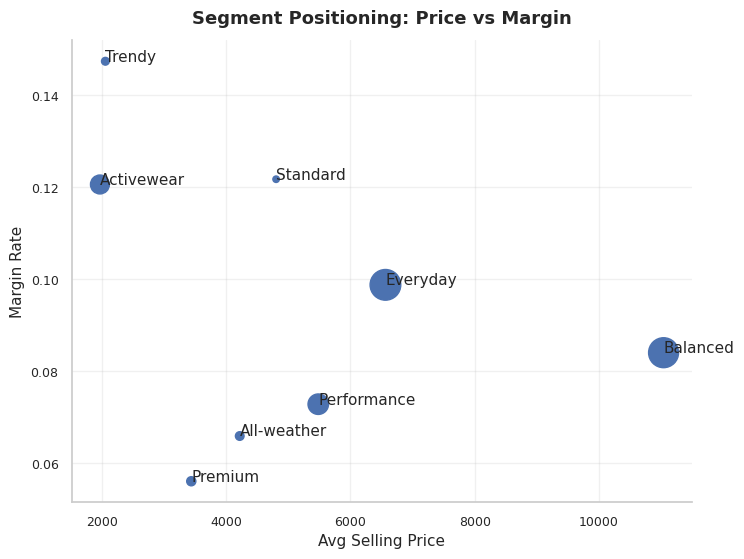

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    seg_analysis['avg_price'],
    seg_analysis['margin_rate'],
    s=seg_analysis['total_revenue'] / 1e7  # scale size
)

for _, row in seg_analysis.iterrows():
    plt.text(row['avg_price'], row['margin_rate'], row['segment'])

plt.xlabel('Avg Selling Price')
plt.ylabel('Margin Rate')
plt.title('Segment Positioning: Price vs Margin')
plt.show()

In [100]:
#!/usr/bin/env python3
"""
Chart 3b v2 — Before / During / After Campaign
Breadth (all campaigns) + Depth (4 selected cases)

Cấu trúc output:
  Row 1 — Overview: scatter net_effect vs discount_spend + distribution histogram
  Row 2 — Deep dive: 4 panels (largest, best, worst, median)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings, os

warnings.filterwarnings('ignore')

DATA_DIR   = '.'          # ← đổi nếu CSV ở thư mục khác
OUTPUT_DIR = 'charts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Palette ────────────────────────────────────────────────────
BLUE   = '#1A3D6E'
BLUE_M = '#2E6DB4'
BLUE_L = '#A8C8EC'
YELLOW = '#D4940A'
YEL_L  = '#F5D080'
RED    = '#B22222'
RED_L  = '#E8897F'
GRAY   = '#555555'
GRAY_L = '#E8E8E8'

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.20, 'grid.color': '#AAAAAA',
    'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

def fmt_M(x, _):
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    return f'{x/1e3:.0f}K'

def fmt_pct(x, _): return f'{x:.0f}%'


# ══════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════
print('Loading data...')
orders      = pd.read_csv(f'{DATA_DIR}/orders.csv',     parse_dates=['order_date'])
order_items = pd.read_csv(f'{DATA_DIR}/order_items.csv')
promotions  = pd.read_csv(f'{DATA_DIR}/promotions.csv', parse_dates=['start_date','end_date'])
sales       = pd.read_csv(f'{DATA_DIR}/sales.csv',      parse_dates=['Date'])

orders_clean = orders[orders['order_status'] != 'cancelled'].copy()

# Daily revenue
daily_rev = (
    orders_clean
    .merge(order_items.groupby('order_id')['unit_price'].sum()
           .mul(order_items.groupby('order_id')['quantity'].sum() / 
                order_items.groupby('order_id')['quantity'].sum())
           .reset_index(), on='order_id', how='left')
)
# Simpler: revenue per order = sum(unit_price * quantity)
oi_rev = (order_items.assign(rev=lambda d: d['unit_price'] * d['quantity'])
          .groupby('order_id')['rev'].sum().reset_index())
daily_rev = (
    orders_clean.merge(oi_rev, on='order_id', how='left')
    .groupby('order_date')['rev'].sum()
    .reset_index().rename(columns={'order_date': 'date', 'rev': 'revenue'})
)
daily_rev['date'] = pd.to_datetime(daily_rev['date'])

promo_windows = list(zip(promotions['start_date'], promotions['end_date']))
WINDOW = 14  # days before/after each campaign


# ══════════════════════════════════════════════════════════════
# ANOMALOUS YEAR DETECTION
#
# Vấn đề: data có cú sập doanh thu ở 2019 (−38.6% YoY).
# Nếu dùng 2019 làm baseline cho campaign năm 2020 (T1) hoặc 2021 (T2 cũ),
# baseline sẽ thấp bất thường → net_effect bị inflate giả tạo.
#
# Giải pháp:
#   - Pre-compute annual revenue, flag năm nào lệch > ANOMALY_THRESHOLD
#     so với median của các năm xung quanh (±2 năm, loại chính nó)
#   - T1 chỉ dùng nếu LY không bị flag anomalous VÀ không có campaign
#   - T2 bị bỏ hoàn toàn (risk quá cao khi có cú sập bất kỳ năm nào)
#   - T3/T4 lọc bỏ ngày thuộc anomalous year khỏi pool ngày sạch
# ══════════════════════════════════════════════════════════════

ANOMALY_THRESHOLD = 0.25   # lệch >25% so với median xung quanh → anomalous
MIN_DAYS          = 7      # cần ít nhất 7 ngày sạch mới tin cậy

# Tính annual revenue và flag anomalous years
_annual_rev = (
    daily_rev.assign(year=daily_rev['date'].dt.year)
    .groupby('year')['revenue'].sum()
)

def _is_anomalous_year(yr):
    """
    True nếu doanh thu năm yr lệch quá ANOMALY_THRESHOLD so với
    median của các năm trong cửa sổ ±2 năm (không tính chính yr).
    """
    window = _annual_rev[
        (_annual_rev.index >= yr - 2) &
        (_annual_rev.index <= yr + 2) &
        (_annual_rev.index != yr)
    ]
    if len(window) < 2:
        return False
    ref = window.median()
    if ref == 0:
        return False
    return abs(_annual_rev.get(yr, ref) - ref) / ref > ANOMALY_THRESHOLD

# Cache để không tính lại nhiều lần
_anomalous_years = {yr for yr in _annual_rev.index if _is_anomalous_year(yr)}
if _anomalous_years:
    print(f'  Anomalous years detected: {sorted(_anomalous_years)} '
          f'(threshold >{ANOMALY_THRESHOLD:.0%} deviation)')
else:
    print('  No anomalous years detected.')

# Pre-compute mask ngày không thuộc anomalous year (dùng lại trong T3/T4)
_mask_not_anomalous = ~daily_rev['date'].dt.year.isin(_anomalous_years)


def _window_has_promo(w_start, w_end):
    """Kiểm tra [w_start, w_end] có overlap với bất kỳ campaign nào không."""
    return any(
        not (w_end < ws or w_start > we)
        for ws, we in promo_windows
    )

# Pre-compute mask ngày không thuộc bất kỳ campaign nào
_mask_no_promo = ~daily_rev['date'].apply(
    lambda d: any(ws <= d <= we for ws, we in promo_windows)
)

def _non_promo_nearby(camp_start, camp_end, radius_weeks=8, extra_years=(0,)):
    """
    Lấy non-promo days trong vòng radius_weeks tuần trước/sau campaign.
    Tự động loại bỏ:
      - Ngày thuộc bất kỳ campaign nào
      - Ngày thuộc anomalous year
      - Window của chính campaign đang xét (và bản offset của nó)
    """
    half = pd.Timedelta(weeks=radius_weeks)
    collected = []
    for yr_offset in extra_years:
        anchor_s = camp_start - pd.DateOffset(years=yr_offset)
        anchor_e = camp_end   - pd.DateOffset(years=yr_offset)
        search_s = anchor_s - half
        search_e = anchor_e + half

        mask_range        = (daily_rev['date'] >= search_s) & (daily_rev['date'] <= search_e)
        mask_excl_camp    = ~((daily_rev['date'] >= camp_start) & (daily_rev['date'] <= camp_end))
        mask_excl_offset  = ~((daily_rev['date'] >= anchor_s)   & (daily_rev['date'] <= anchor_e))
        combined = (mask_range
                    & mask_excl_camp
                    & mask_excl_offset
                    & _mask_no_promo          # không thuộc campaign nào
                    & _mask_not_anomalous)    # không thuộc anomalous year
        collected.append(daily_rev.loc[combined, 'revenue'])

    return pd.concat(collected) if collected else pd.Series(dtype=float)


def get_baseline(camp_start, camp_end):
    """
    Trả về (baseline_daily_revenue, method_label).

    Tầng 1 — same period năm ngoái
              Điều kiện: (a) không overlap campaign  VÀ  (b) LY không phải anomalous year
              Lý do check (b): dùng năm sập (2019) làm baseline cho 2020 → inflate net_effect
    [T2 đã bỏ] — risk dùng năm anomalous quá cao khi data có cú sập
    Tầng 3 — non-promo days ±8 tuần, cùng năm   → giữ seasonality, bỏ anomalous days
    Tầng 4 — non-promo days ±8 tuần, ±1 năm     → mở rộng sample, vẫn bỏ anomalous days
    Tầng 5 — global median (non-promo, non-anomalous) → fallback cuối
    """
    # ── Tầng 1: same period năm ngoái ──────────────────────────
    ly_s    = camp_start - pd.DateOffset(years=1)
    ly_e    = camp_end   - pd.DateOffset(years=1)
    ly_year = ly_s.year

    t1_clean = (
        not _window_has_promo(ly_s, ly_e)   # (a) không có campaign LY
        and ly_year not in _anomalous_years  # (b) LY không phải năm bất thường
    )
    if t1_clean:
        mask = (daily_rev['date'] >= ly_s) & (daily_rev['date'] <= ly_e)
        vals = daily_rev.loc[mask, 'revenue']
        if len(vals) >= MIN_DAYS:
            return vals.median(), 'T1: same period LY'

    # ── Tầng 3: non-promo nearby, cùng năm ─────────────────────
    # (T2 đã bỏ — xem comment trên)
    vals = _non_promo_nearby(camp_start, camp_end, radius_weeks=8, extra_years=(0,))
    if len(vals) >= MIN_DAYS:
        return vals.median(), 'T3: non-promo nearby (same yr)★'

    # ── Tầng 4: mở rộng sang ±1 năm ────────────────────────────
    vals = _non_promo_nearby(camp_start, camp_end, radius_weeks=8, extra_years=(0, 1))
    if len(vals) >= MIN_DAYS:
        return vals.median(), 'T4: non-promo nearby (±1yr)★★'

    # ── Tầng 5: global median (loại anomalous + promo days) ─────
    safe_vals = daily_rev.loc[_mask_no_promo & _mask_not_anomalous, 'revenue']
    return (safe_vals.median() if len(safe_vals) > 0
            else daily_rev['revenue'].median()), 'T5: global median★★★'


# ══════════════════════════════════════════════════════════════
# STEP 1 — COMPUTE METRICS FOR ALL CAMPAIGNS
# ══════════════════════════════════════════════════════════════
print('Computing metrics for all campaigns...')

# Total discount per campaign (for spend axis)
disc_per_promo = (
    order_items[order_items['promo_id'].notna()]
    .groupby('promo_id')['discount_amount'].sum()
    .reset_index().rename(columns={'discount_amount': 'total_discount_spend'})
)

records = []
for _, row in promotions.iterrows():
    s, e = row['start_date'], row['end_date']
    before = daily_rev[(daily_rev['date'] >= s - pd.Timedelta(days=WINDOW)) &
                       (daily_rev['date'] <  s)]['revenue'].values
    during = daily_rev[(daily_rev['date'] >= s) &
                       (daily_rev['date'] <= e)]['revenue'].values
    after  = daily_rev[(daily_rev['date'] >  e) &
                       (daily_rev['date'] <= e + pd.Timedelta(days=WINDOW))]['revenue'].values

    if len(during) == 0:
        continue

    baseline, method = get_baseline(s, e)
    total_days = len(during) + WINDOW
    net_effect = (during.sum() + (after.sum() if len(after) else 0)) - baseline * total_days

    disc_spend = disc_per_promo.loc[
        disc_per_promo['promo_id'] == row['promo_id'], 'total_discount_spend'
    ].values
    disc_spend = float(disc_spend[0]) if len(disc_spend) else 0.0

    records.append({
        'promo_id':      row['promo_id'],
        'promo_name':    row['promo_name'],
        'start_date':    s,
        'end_date':      e,
        'rev_before':    before,
        'rev_during':    during,
        'rev_after':     after,
        'baseline':      baseline,
        'net_effect':    net_effect,
        'disc_spend':    disc_spend,
        'pull_fwd':      during.mean() / baseline if baseline > 0 else np.nan,
        'hangover':      after.mean()  / baseline if baseline > 0 and len(after) else np.nan,
        'method':        method,
    })

all_camp = pd.DataFrame([{k: v for k, v in r.items()
                           if k not in ('rev_before','rev_during','rev_after')}
                          for r in records])

pct_negative   = (all_camp['net_effect'] < 0).mean() * 100
pct_cannibal   = (all_camp['hangover'] < 1).mean() * 100
median_pull    = all_camp['pull_fwd'].median()
print(f'  Total campaigns: {len(all_camp)}')
print(f'  Net effect < 0:  {pct_negative:.0f}%')
print(f'  Hangover < 1:    {pct_cannibal:.0f}%')


# ══════════════════════════════════════════════════════════════
# STEP 2 — SELECT 4 DEEP-DIVE CAMPAIGNS
# ══════════════════════════════════════════════════════════════
valid = all_camp.dropna(subset=['net_effect','hangover'])

idx_largest  = all_camp['disc_spend'].idxmax()
idx_best     = valid['net_effect'].idxmax()
idx_worst    = valid['net_effect'].idxmin()
# Median anchor: closest to median net_effect (exclude the other 3)
exclude = {idx_largest, idx_best, idx_worst}
rest    = valid[~valid.index.isin(exclude)]
if len(rest):
    med_ne  = valid['net_effect'].median()
    idx_mid = (rest['net_effect'] - med_ne).abs().idxmin()
else:
    idx_mid = idx_best  # fallback

deep_indices  = [idx_largest, idx_best, idx_worst, idx_mid]
deep_labels   = ['Largest spend', 'Best net effect', 'Worst net effect', 'Median (anchor)']
deep_colors   = [BLUE_M, '#1B6B3A', RED, GRAY]
deep_records  = {i: next(r for r in records if r['promo_id'] == all_camp.loc[i, 'promo_id'])
                 for i in deep_indices}


# ══════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor('white')

outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.42,
                          top=0.93, bottom=0.06, left=0.06, right=0.97)

# ── ROW 1: Overview ──────────────────────────────────────────
gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0],
                                          wspace=0.38, width_ratios=[1.6, 1])
ax_sc  = fig.add_subplot(gs_top[0])   # scatter
ax_his = fig.add_subplot(gs_top[1])   # histogram

# --- Scatter: disc_spend vs net_effect ---
ne    = all_camp['net_effect'].values
ds    = all_camp['disc_spend'].values
color_sc = np.where(ne >= 0, BLUE_M, RED)
alpha_sc = np.where(all_camp.index.isin(deep_indices), 1.0, 0.35)
sz_sc    = np.where(all_camp.index.isin(deep_indices), 100, 38)

for i, row_c in all_camp.iterrows():
    ax_sc.scatter(row_c['disc_spend'], row_c['net_effect'],
                  color=BLUE_M if row_c['net_effect'] >= 0 else RED,
                  alpha=float(alpha_sc[i]), s=float(sz_sc[i]),
                  edgecolors='white' if i in deep_indices else 'none',
                  linewidths=1.2, zorder=3)

# Annotate 4 deep-dive points
for i, lbl, clr in zip(deep_indices, deep_labels, deep_colors):
    r = all_camp.loc[i]
    ax_sc.scatter(r['disc_spend'], r['net_effect'],
                  color=clr, s=120, edgecolors='white', linewidths=1.4, zorder=5)
    ax_sc.annotate(lbl, (r['disc_spend'], r['net_effect']),
                   xytext=(8, 5), textcoords='offset points',
                   fontsize=8, color=clr, fontweight='bold')

ax_sc.axhline(0, color=RED, lw=1.8, ls='--', alpha=0.7, zorder=4)
ax_sc.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))
ax_sc.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))
ax_sc.set_xlabel('Total discount spend / campaign', labelpad=7)
ax_sc.set_ylabel('Net effect (revenue vs baseline)', labelpad=7)
ax_sc.set_title('All campaigns — Discount spend vs Net effect', fontweight='bold')

# Baseline method breakdown
method_counts = all_camp['method'].value_counts()
tier_summary  = '  |  '.join(f"{m.split(':')[0]}: {c}" for m, c in method_counts.items())

# Summary stats box
stats_txt = (f'{pct_negative:.0f}% campaigns with net_effect < 0\n'
             f'{pct_cannibal:.0f}% campaigns with hangover < 1\n'
             f'Median pull-forward: {median_pull:.2f}×\n'
             f'Baseline: {tier_summary}')
ax_sc.text(0.02, 0.98, stats_txt, transform=ax_sc.transAxes,
           va='top', ha='left', fontsize=8.5,
           color=RED if pct_negative > 50 else BLUE,
           bbox=dict(facecolor='white', edgecolor=GRAY_L,
                     boxstyle='round,pad=0.4', alpha=0.92))

# --- Histogram: net_effect distribution ---
ne_vals = all_camp['net_effect'].dropna().values
bins    = min(20, max(8, len(ne_vals) // 3))
neg_mask = ne_vals < 0
ax_his.hist(ne_vals[~neg_mask], bins=bins, color=BLUE_M, alpha=0.80, label='Net effect ≥ 0', zorder=3)
ax_his.hist(ne_vals[neg_mask],  bins=bins, color=RED,    alpha=0.80, label='Net effect < 0', zorder=3)
ax_his.axvline(0, color=RED, lw=1.8, ls='--', alpha=0.7)
ax_his.axvline(np.median(ne_vals), color=YELLOW, lw=1.8, ls='-', alpha=0.9,
               label=f'Median: {fmt_M(np.median(ne_vals), None)}')
ax_his.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))
ax_his.set_xlabel('Net effect', labelpad=7)
ax_his.set_ylabel('Number of campaigns', labelpad=7)
ax_his.set_title('Distribution of net effect \n(across all campaigns)', fontweight='bold')
ax_his.legend(frameon=False, fontsize=8.5)

# ── ROW 2: Deep dive ─────────────────────────────────────────
gs_bot = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[1], wspace=0.38)
axes_d = [fig.add_subplot(gs_bot[j]) for j in range(4)]

for ax, i, lbl, clr in zip(axes_d, deep_indices, deep_labels, deep_colors):
    r = deep_records[i]
    nb, nd, na = len(r['rev_before']), len(r['rev_during']), len(r['rev_after'])
    all_r = np.concatenate([r['rev_before'], r['rev_during'], r['rev_after']])
    if len(all_r) == 0:
        ax.set_visible(False)
        continue

    x = np.arange(len(all_r))
    bar_colors = [BLUE_L]*nb + [BLUE_M]*nd + [RED_L]*na

    ax.bar(x, all_r, color=bar_colors, width=0.92, edgecolor='none', zorder=2)
    ax.axhline(r['baseline'], color=YELLOW, lw=2, ls='--', zorder=3)

    for xv in [nb - 0.5, nb + nd - 0.5]:
        ax.axvline(xv, color=GRAY, lw=0.8, ls=':', zorder=4)

    ymax = all_r.max()
    ax.set_ylim(0, ymax * 1.30)

    # Period labels
    for txt, xpos in [
        ('Before', nb/2 - 0.5),
        ('During', nb + nd/2 - 0.5),
        ('After',  nb + nd + na/2 - 0.5),
    ]:
        if xpos >= 0 and len(all_r) > 0:
            ax.text(xpos, ymax * 1.08, txt, ha='center', fontsize=7.5,
                    color=BLUE if txt == 'During' else GRAY)

    # Metrics box
    ne_c = '#1B6B3A' if r['net_effect'] >= 0 else RED
    metrics = (f"Pull-fwd: {r['pull_fwd']:.2f}×\n"
               f"Hangover: {r['hangover']:.2f}×\n"
               f"Net: {r['net_effect']/1e6:+.1f}M")
    ax.text(0.5, 0.03, metrics, transform=ax.transAxes,
            ha='center', va='bottom', fontsize=8, color=ne_c, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor=ne_c,
                      boxstyle='round,pad=0.25', alpha=0.93))

    # Title: label + campaign name
    camp_name = all_camp.loc[i, 'promo_name'][:22]
    ax.set_title(f'{lbl}\n{camp_name}', fontsize=8.5, fontweight='bold',
                 color=clr, pad=6)
    ax.set_xticks([])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))

    # Baseline method footnote — chỉ hiện khi không phải T1/T2 (sạch nhất)
    tier = r['method']
    if '★' in tier:
        stars = tier.count('★')
        note  = ['', 'seasonal nearby', 'nearby ±1yr', 'global median'][min(stars, 3)]
        ax.text(0.5, -0.07, f'baseline: {note}', transform=ax.transAxes,
                ha='center', fontsize=7, color=GRAY, style='italic')

# ── Global legend (Row 2) ─────────────────────────────────────
leg_handles = [
    mpatches.Patch(color=BLUE_L,  label=f'Before ({WINDOW}d)'),
    mpatches.Patch(color=BLUE_M,  label='During campaign'),
    mpatches.Patch(color=RED_L,   label=f'After ({WINDOW}d)'),
    Line2D([0],[0], color=YELLOW, lw=2, ls='--', label='Baseline'),
]
fig.legend(handles=leg_handles, loc='lower center',
           bbox_to_anchor=(0.5, -0.01), ncol=4, frameon=False, fontsize=9.5)

# ── Super title ───────────────────────────────────────────────
fig.suptitle('Chart 3b — Campaign Cannibalization Analysis  ·  Breadth + Depth',
             fontsize=13, fontweight='bold', y=0.97)

out_path = f'{OUTPUT_DIR}/chart_3b_v2.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close()
print(f'✓  Saved: {out_path}')

Loading data...
  Anomalous years detected: [2012] (threshold >25% deviation)
Computing metrics for all campaigns...
  Total campaigns: 50
  Net effect < 0:  52%
  Hangover < 1:    62%
✓  Saved: charts/chart_3b_v2.png


In [101]:
#!/usr/bin/env python3
"""
Charts 3c & 3d — Promotion Analysis  (FIXED VERSION)
Datathon 2026 · Fashion E-commerce Vietnam

BUGS FIXED:
  3d Panel C — Return rate = 100%:
      Root cause: returns_df có nhiều rows per order_id (1 row per product returned).
      Khi merge không deduplicate → order có 3 sản phẩm trả = 3 rows True
      → tất cả matched rows = True → mean() = 100%.
      Fix: drop_duplicates('order_id') trên returns_df TRƯỚC khi merge
           + fillna(False) để tính đúng denominator (tổng đơn, kể cả đơn không trả).

  3d Panel C — ord_flag duplicates:
      ord_flag join customer → all orders → nhiều rows per order nếu customer
      có orders được join nhiều lần. Thêm drop_duplicates('order_id') sau merge.

  3c — Không có bug logic, chỉ giữ nguyên.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')

DATA_DIR   = '.'
OUTPUT_DIR = 'charts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Palette ────────────────────────────────────────────────────
BLUE   = '#1A3D6E'
BLUE_M = '#2E6DB4'
BLUE_L = '#A8C8EC'
YELLOW = '#D4940A'
YEL_L  = '#F5D080'
RED    = '#B22222'
RED_L  = '#E8897F'
GRAY   = '#4A4A4A'
GRAY_L = '#EFEFEF'

CAT_COLORS = [BLUE_M, YELLOW, RED, '#5B8DB8', '#C47A2A', '#8B2020']

plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid':       True,  'grid.alpha': 0.18, 'grid.color': '#B0B0B0',
    'axes.facecolor':  'white', 'figure.facecolor': 'white',
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
})

def fmt_pct(x, _):  return f'{x:.0f}%'
def fmt_M(x, _):
    if abs(x) >= 1e9: return f'{x/1e9:.1f}B'
    if abs(x) >= 1e6: return f'{x/1e6:.1f}M'
    return f'{x/1e3:.0f}K'


# ══════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════
print('Loading data...')
orders      = pd.read_csv(f'{DATA_DIR}/orders.csv',     parse_dates=['order_date'])
order_items = pd.read_csv(f'{DATA_DIR}/order_items.csv')
products    = pd.read_csv(f'{DATA_DIR}/products.csv')
promotions  = pd.read_csv(f'{DATA_DIR}/promotions.csv', parse_dates=['start_date','end_date'])
returns_df  = pd.read_csv(f'{DATA_DIR}/returns.csv',    parse_dates=['return_date'])
reviews_df  = pd.read_csv(f'{DATA_DIR}/reviews.csv')

orders_clean = orders[orders['order_status'] != 'cancelled'].copy()

base = (
    order_items
    .merge(orders_clean[['order_id','order_date','customer_id']], on='order_id')
    .merge(products[['product_id','cogs','price','category','segment']], on='product_id')
)
base['revenue_line']  = base['unit_price'] * base['quantity']
base['cogs_line']     = base['cogs']       * base['quantity']
base['list_revenue']  = base['price']      * base['quantity']
base['gross_profit']  = base['revenue_line'] - base['cogs_line'] - base['discount_amount']
base['margin_rate']   = np.where(base['revenue_line'] > 0,
                                  base['gross_profit'] / base['revenue_line'], np.nan)
base['discount_rate'] = np.where(base['list_revenue'] > 0,
                                  1 - base['revenue_line'] / base['list_revenue'], np.nan)
base['has_promo']     = base['discount_amount'] > 0

promo_windows = list(zip(promotions['start_date'], promotions['end_date']))
def in_campaign(d):
    return any(ws <= d <= we for ws, we in promo_windows)

# ── Pre-compute: returned order_ids deduplicated (dùng cho 3d) ──
# FIX: 1 order_id chỉ xuất hiện 1 lần — bất kể trả bao nhiêu sản phẩm
returned_order_ids = (
    returns_df[['order_id']]
    .drop_duplicates('order_id')
    .assign(returned=True)
)


# ══════════════════════════════════════════════════════════════
# CHART 3c — Discount Depth vs Gross Margin
# Không có bug logic — giữ nguyên structure, chỉ clean nhỏ
# ══════════════════════════════════════════════════════════════
def chart_3c():
    print('Building Chart 3c...')

    promo_base = base[base['has_promo'] & base['promo_id'].notna()].copy()

    def agg_promo(g):
        return pd.Series({
            'avg_discount_rate': g['discount_rate'].mean() * 100,
            'avg_margin_rate':   g['margin_rate'].mean()   * 100,
            'total_revenue':     g['revenue_line'].sum(),
            'num_orders':        g['order_id'].nunique(),
            'category':          g['category'].value_counts().index[0],
            'segment':           g['segment'].value_counts().index[0],
        })

    promo_stats = (
        promo_base.groupby('promo_id')
        .apply(agg_promo).reset_index()
        .dropna(subset=['avg_discount_rate', 'avg_margin_rate'])
    )

    max_orders  = promo_stats['num_orders'].max()
    bubble_size = (promo_stats['num_orders'] / max_orders) * 420 + 35
    cats        = sorted(promo_stats['category'].unique())
    color_map   = {c: CAT_COLORS[i % len(CAT_COLORS)] for i, c in enumerate(cats)}
    worst5      = (promo_stats[promo_stats['avg_margin_rate'] < 0]
                   .nsmallest(5, 'avg_margin_rate').reset_index(drop=True))
    worst_ids   = set(worst5['promo_id'].tolist())

    fig = plt.figure(figsize=(15, 8.5))
    fig.suptitle('Chart 3c — Discount Depth vs Gross Margin\n'
                 'mỗi điểm = 1 promotion  ·  size = số đơn hàng',
                 fontsize=13, fontweight='bold', y=0.99)

    gs = gridspec.GridSpec(
        2, 2, figure=fig,
        height_ratios=[3.2, 1], width_ratios=[2.2, 1],
        hspace=0.38, wspace=0.36,
        left=0.07, right=0.97, top=0.91, bottom=0.05,
    )
    ax_sc  = fig.add_subplot(gs[0, 0])
    ax_be  = fig.add_subplot(gs[0, 1])
    ax_tbl = fig.add_subplot(gs[1, :])

    breakeven_data = {}

    for cat in cats:
        m    = promo_stats['category'] == cat
        df_c = promo_stats[m]
        clr  = color_map[cat]

        normal_m = m & ~promo_stats['promo_id'].isin(worst_ids)
        ax_sc.scatter(
            promo_stats.loc[normal_m, 'avg_discount_rate'],
            promo_stats.loc[normal_m, 'avg_margin_rate'],
            s=bubble_size[normal_m], color=clr,
            alpha=0.65, edgecolors='white', linewidths=0.6, zorder=3,
        )
        worst_m = m & promo_stats['promo_id'].isin(worst_ids)
        if worst_m.any():
            ax_sc.scatter(
                promo_stats.loc[worst_m, 'avg_discount_rate'],
                promo_stats.loc[worst_m, 'avg_margin_rate'],
                s=bubble_size[worst_m] + 60, color=clr,
                alpha=0.85, edgecolors=RED, linewidths=2.0, zorder=5,
            )
        if len(df_c) >= 4:
            x_ = df_c['avg_discount_rate'].values
            y_ = df_c['avg_margin_rate'].values
            slope, intercept, *_ = stats.linregress(x_, y_)
            x_fit = np.linspace(x_.min(), x_.max(), 80)
            ax_sc.plot(x_fit, slope * x_fit + intercept,
                       color=clr, lw=1.6, ls='--', alpha=0.45, zorder=2)
            if slope < 0:
                be = -intercept / slope
                breakeven_data[cat] = round(be, 1)

    ax_sc.axhline(0, color=RED, lw=2.0, ls='-', zorder=4, alpha=0.75, label='Margin = 0')
    ax_sc.set_xlim(left=0)
    ax_sc.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
    ax_sc.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
    ax_sc.set_xlabel('Avg actual discount rate (%)', labelpad=8)
    ax_sc.set_ylabel('Avg gross margin rate (%)', labelpad=8)
    ax_sc.set_title('Scatter: discount depth vs gross margin', fontsize=11, pad=8)

    ymin, ymax = ax_sc.get_ylim()
    for cat, be in breakeven_data.items():
        clr     = color_map[cat]
        x_range = promo_stats.loc[promo_stats['category'] == cat, 'avg_discount_rate']
        if x_range.min() - 8 < be < x_range.max() + 5:
            ax_sc.axvline(be, color=clr, lw=1.0, ls=':', alpha=0.40, zorder=1)
            ax_sc.text(be + 0.4, ymin + (ymax - ymin) * 0.04,
                       f'BE {be:.0f}%', ha='left', fontsize=8,
                       color=clr, fontweight='bold', alpha=0.85)

    cat_h   = [mpatches.Patch(color=color_map[c], alpha=0.80, label=c) for c in cats]
    sz_h    = [ax_sc.scatter([], [], s=(n / max_orders) * 420 + 35, color=GRAY,
                              alpha=0.35, label=l)
               for l, n in [('100 đơn', 100), ('300 đơn', 300), ('500 đơn', 500)]]
    worst_h = [ax_sc.scatter([], [], s=90, color=GRAY, edgecolors=RED,
                              linewidths=2, alpha=0.85, label='Top 5 worst margin')]
    leg1 = ax_sc.legend(handles=cat_h, frameon=False, fontsize=9,
                        loc='lower left', title='Category',
                        title_fontsize=8.5, labelspacing=0.35)
    ax_sc.add_artist(leg1)
    ax_sc.legend(handles=sz_h + worst_h, frameon=False, fontsize=8.5,
                 loc='upper right', labelspacing=0.35)

    if breakeven_data:
        be_cats = list(breakeven_data.keys())
        be_vals = list(breakeven_data.values())
        y_pos   = np.arange(len(be_cats))
        for i, (cat, val) in enumerate(zip(be_cats, be_vals)):
            clr     = color_map[cat]
            ceiling = max(0, val - 5)
            ax_be.barh(i, val,     height=0.40, color=clr, alpha=0.80, edgecolor='none')
            ax_be.barh(i, ceiling, height=0.40, color=clr, alpha=0.28, edgecolor='none')
            ax_be.text(val + 0.2, i, f'{val:.0f}%',
                       va='center', fontsize=10.5, fontweight='bold', color=clr)
            if ceiling > 1.5:
                ax_be.text(ceiling * 0.5, i, f'ceiling {ceiling:.0f}%',
                           va='center', ha='center', fontsize=8,
                           color=clr, fontweight='bold', alpha=0.72)
        ax_be.set_yticks(y_pos)
        ax_be.set_yticklabels(be_cats, fontsize=10.5)
        ax_be.set_xlim(0, max(be_vals) * 1.30)
        ax_be.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
        ax_be.set_xlabel('Discount rate (%)', labelpad=8)
        ax_be.grid(axis='x', alpha=0.18)
        ax_be.grid(axis='y', alpha=0)
        ax_be.set_title('Breakeven rate theo category\n(ceiling = BE − 5pp)',
                        fontsize=10.5, fontweight='bold', pad=8)
        ax_be.legend(
            handles=[mpatches.Patch(color=GRAY, alpha=0.80, label='Breakeven rate'),
                     mpatches.Patch(color=GRAY, alpha=0.28, label='Safe ceiling (−5pp)')],
            frameon=False, fontsize=8.5, loc='lower right', labelspacing=0.4)
    else:
        ax_be.text(0.5, 0.5, 'Không đủ data cho regression',
                   transform=ax_be.transAxes, ha='center', va='center',
                   fontsize=10, color=GRAY)

    ax_tbl.axis('off')
    if len(worst5):
        col_labels = ['Rank', 'Promo ID', 'Category', 'Avg discount', 'Avg margin', 'Đơn hàng']
        rows = []
        for idx, r in worst5.iterrows():
            rows.append([f'#{idx+1}', r['promo_id'], r['category'],
                         f"{r['avg_discount_rate']:.1f}%",
                         f"{r['avg_margin_rate']:.1f}%",
                         f"{int(r['num_orders']):,}"])
        tbl = ax_tbl.table(cellText=rows, colLabels=col_labels,
                           cellLoc='center', loc='center',
                           bbox=[0.0, 0.0, 1.0, 1.0])
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        for j in range(len(col_labels)):
            tbl[0, j].set_facecolor(RED)
            tbl[0, j].set_text_props(color='white', fontweight='bold')
            tbl[0, j].set_edgecolor('white')
        for i in range(1, len(rows) + 1):
            for j in range(len(col_labels)):
                tbl[i, j].set_facecolor('#FDF0F0' if i % 2 else 'white')
                tbl[i, j].set_edgecolor('#EEEEEE')
                if j == 4:
                    tbl[i, j].set_text_props(color=RED, fontweight='bold')
        ax_tbl.set_title('Top 5 promotions vượt breakeven  (cần redesign)',
                         fontsize=10, fontweight='bold', pad=6, color=RED, loc='left')

    path = f'{OUTPUT_DIR}/chart_3c.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  ✓ Saved: {path}')


# ══════════════════════════════════════════════════════════════
# CHART 3d — Cohort Retention Analysis
# ══════════════════════════════════════════════════════════════
def chart_3d():
    print('Building Chart 3d...')

    orders_clean_d = orders[orders['order_status'] != 'cancelled'].copy()
    orders_clean_d['order_date'] = pd.to_datetime(orders_clean_d['order_date'])

    # ── First order per customer ────────────────────────────────
    first_ord = (
        orders_clean_d.groupby('customer_id')['order_date'].min()
        .reset_index().rename(columns={'order_date': 'first_order_date'})
    )
    first_ord['is_promo'] = first_ord['first_order_date'].apply(in_campaign)

    cohort_p = first_ord[first_ord['is_promo']].copy()
    cohort_o = first_ord[~first_ord['is_promo']].copy()
    max_date  = orders_clean_d['order_date'].max()

    # ── Retention ──────────────────────────────────────────────
    all_sub = (
        orders_clean_d[['customer_id', 'order_date']]
        .merge(first_ord[['customer_id', 'first_order_date']], on='customer_id')
    )
    all_sub = all_sub[all_sub['order_date'] > all_sub['first_order_date']]

    def retention_at(cohort, month_n, window_days=15):
        offset = pd.Timedelta(days=month_n * 30)
        c = cohort[cohort['first_order_date'] + offset <= max_date].copy()
        if len(c) < 10:
            return np.nan
        c['ws'] = c['first_order_date'] + offset - pd.Timedelta(days=window_days)
        c['we'] = c['first_order_date'] + offset + pd.Timedelta(days=window_days)
        merged  = c.merge(all_sub[['customer_id', 'order_date']], on='customer_id', how='left')
        merged['in_w'] = (merged['order_date'] >= merged['ws']) & \
                         (merged['order_date'] <= merged['we'])
        ret = merged.groupby('customer_id')['in_w'].any()
        return ret.reindex(c['customer_id'], fill_value=False).mean() * 100

    months   = [1, 3, 6]
    m_labels = ['Tháng 1', 'Tháng 3', 'Tháng 6']
    ret_p = [retention_at(cohort_p, m) for m in months]
    ret_o = [retention_at(cohort_o, m) for m in months]

    # ── Net CLV ────────────────────────────────────────────────
    refunds_agg  = returns_df.groupby('order_id')['refund_amount'].sum().reset_index()
    order_profit = (
        base.groupby(['order_id', 'customer_id'])['gross_profit'].sum().reset_index()
        .merge(refunds_agg, on='order_id', how='left')
    )
    order_profit['refund_amount'] = order_profit['refund_amount'].fillna(0)
    order_profit['adj_profit']    = order_profit['gross_profit'] - order_profit['refund_amount']
    clv = (
        order_profit.groupby('customer_id')['adj_profit'].sum()
        .reset_index().rename(columns={'adj_profit': 'net_clv'})
    )
    first_clv = first_ord.merge(clv, on='customer_id', how='left')
    clv_p     = first_clv.loc[first_clv['is_promo'],  'net_clv'].dropna()
    clv_o     = first_clv.loc[~first_clv['is_promo'], 'net_clv'].dropna()
    clip_val  = first_clv['net_clv'].quantile(0.97)
    clv_p     = clv_p.clip(upper=clip_val)
    clv_o     = clv_o.clip(upper=clip_val)

    # ── Return rate — FIX ──────────────────────────────────────
    # Bug cũ: returns_df nhiều rows/order_id → merge tạo duplicate True → mean()=100%
    # Fix:
    #   1. returned_order_ids: deduplicate returns_df theo order_id (global, tính ở đầu)
    #   2. fillna(False) sau left merge → đơn không trả = False, không bị bỏ khỏi denominator
    #   3. drop_duplicates('order_id') trên kết quả merge để đảm bảo 1 row / order

    ord_flag = (
        first_ord[['customer_id', 'is_promo']]
        .merge(orders_clean_d[['order_id', 'customer_id']], on='customer_id')
    )

    # FIX: return rate
    ret_merged = (
        ord_flag
        .merge(returned_order_ids, on='order_id', how='left')  # returned_order_ids đã dedup
        .drop_duplicates('order_id')                            # safety: 1 row per order
    )
    ret_merged['returned'] = ret_merged['returned'].fillna(False)  # FIX: unmatched = not returned
    ret_rate = ret_merged.groupby('is_promo')['returned'].mean() * 100

    # Print sanity check
    rr_p = float(ret_rate.get(True,  0))
    rr_o = float(ret_rate.get(False, 0))
    print(f'  Return rate — Promo: {rr_p:.1f}%  Organic: {rr_o:.1f}%')
    if rr_p > 50 or rr_o > 50:
        print('  ⚠ Return rate still high — check returns_df scope (line items vs orders)')

    # ── Avg rating ─────────────────────────────────────────────
    # reviews_df có thể nhiều rows/order (1 review per product trong đơn)
    # Deduplicate theo order_id để lấy đại diện mỗi đơn 1 lần
    reviews_dedup = (
        reviews_df[['order_id', 'rating']]
        .drop_duplicates('order_id')   # 1 rating per order
    )
    avg_rating = (
        ord_flag
        .merge(reviews_dedup, on='order_id', how='left')
        .drop_duplicates('order_id')
        .groupby('is_promo')['rating'].mean()
    )

    rt_p = float(avg_rating.get(True,  0))
    rt_o = float(avg_rating.get(False, 0))
    print(f'  Avg rating  — Promo: {rt_p:.2f}★  Organic: {rt_o:.2f}★')
    print(f'  Rating gap: {abs(rt_p - rt_o):.2f} → '
          + ('not statistically meaningful (< 0.1)' if abs(rt_p - rt_o) < 0.1
             else 'meaningful gap'))

    # ── Panel D: Second-purchase discount dependency ──────────
    # Logic: trong số lần mua lại (sau first order) của từng cohort,
    # bao nhiêu % là đơn có promo? → Nếu cao → khách bị train chỉ mua khi sale
    repeat_orders = (
        orders_clean_d[['customer_id', 'order_id', 'order_date']]
        .merge(first_ord[['customer_id', 'first_order_date', 'is_promo']], on='customer_id')
    )
    repeat_orders = repeat_orders[
        repeat_orders['order_date'] > repeat_orders['first_order_date']
    ]

    # Xác định order có promo: check trong order_items nếu có bất kỳ dòng nào discount > 0
    promo_order_ids = set(
        order_items[order_items['discount_amount'] > 0]['order_id'].unique()
    )
    repeat_orders['order_has_promo'] = repeat_orders['order_id'].isin(promo_order_ids)

    dep_data = {}
    for grp_name, grp_val in [('Promo cohort', True), ('Organic cohort', False)]:
        sub = repeat_orders[repeat_orders['is_promo'] == grp_val]
        if len(sub) == 0:
            dep_data[grp_name] = {
                'pct_promo_dependent': np.nan,
                'pct_never_promo':     np.nan,
                'pct_always_promo':    np.nan,
                'n_customers': 0,
            }
            continue
        # Per customer: % of their repeat orders that used promo
        cust_dep = sub.groupby('customer_id')['order_has_promo'].mean() * 100
        dep_data[grp_name] = {
            'pct_promo_dependent': cust_dep.mean(),           # avg % repeat orders dùng promo
            'pct_never_promo':     (cust_dep == 0).mean() * 100,   # % chưa bao giờ cần promo
            'pct_always_promo':    (cust_dep == 100).mean() * 100, # % luôn luôn cần promo
            'n_customers':         len(cust_dep),
        }
        print(f'  [{grp_name}] repeat customers={len(cust_dep):,}  '
              f'avg_promo_dep={cust_dep.mean():.1f}%  '
              f'always={dep_data[grp_name]["pct_always_promo"]:.1f}%  '
              f'never={dep_data[grp_name]["pct_never_promo"]:.1f}%')

    # ══ FIGURE ═══════════════════════════════════════════════════
    fig = plt.figure(figsize=(20, 6.5))
    fig.suptitle('Chart 3d — Promo Cohort vs Organic Cohort  ·  Customer Quality Analysis',
                 fontsize=13, fontweight='bold', y=1.02)

    gs   = gridspec.GridSpec(1, 4, figure=fig, wspace=0.42,
                              left=0.05, right=0.97, top=0.88, bottom=0.13)
    axes = [fig.add_subplot(gs[j]) for j in range(4)]

    # ── Panel A: Retention curve ──────────────────────────────
    ax = axes[0]
    x_ = np.arange(len(m_labels))
    ax.plot(x_, ret_p, color=YELLOW, lw=2.5, marker='o', ms=8, zorder=4,
            label=f'Promo  (n={len(cohort_p):,})')
    ax.plot(x_, ret_o, color=BLUE_M,  lw=2.5, marker='s', ms=8, zorder=4,
            label=f'Organic  (n={len(cohort_o):,})')
    ax.fill_between(x_, ret_p, ret_o, alpha=0.08, color=GRAY)

    for vals, clr in [(ret_p, YELLOW), (ret_o, BLUE_M)]:
        for xi, v in enumerate(vals):
            if pd.notna(v):
                ax.text(xi, v + 0.15, f'{v:.1f}%',
                        ha='center', va='bottom', fontsize=7.5,
                        color=clr, fontweight='bold')

    gaps = [o - p for p, o in zip(ret_p, ret_o) if pd.notna(p) and pd.notna(o)]
    if gaps:
        gap_lines = [f'{lbl}: Δ{g:+.1f}pp' for lbl, g in zip(m_labels, gaps)]
        box_clr   = RED if all(g > 0 for g in gaps) else BLUE_M
        ax.text(0.98, 0.98, '\n'.join(gap_lines),
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color=box_clr, fontweight='bold',
                bbox=dict(facecolor='white', edgecolor=box_clr,
                          boxstyle='round,pad=0.35', alpha=0.90))

    ax.set_xticks(x_)
    ax.set_xticklabels(m_labels, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
    ax.set_ylabel('Retention rate (%)', labelpad=7)
    ax.set_title('A — Retention rate\ntheo thời gian', fontsize=10.5, fontweight='bold', pad=8)
    ax.legend(frameon=False, fontsize=8, loc='lower left', labelspacing=0.3)

    # ── Panel B: CLV violin ───────────────────────────────────
    ax = axes[1]
    clv_df = pd.DataFrame({
        'CLV':    pd.concat([clv_p, clv_o], ignore_index=True),
        'Cohort': ['Promo'] * len(clv_p) + ['Organic'] * len(clv_o),
    })
    sns.violinplot(data=clv_df, x='Cohort', y='CLV',
                   palette={'Promo': YELLOW, 'Organic': BLUE_M},
                   inner='quartile', ax=ax, linewidth=0.9, cut=0, saturation=0.85)

    med_p_clv = clv_df[clv_df['Cohort'] == 'Promo']['CLV'].median()
    med_o_clv = clv_df[clv_df['Cohort'] == 'Organic']['CLV'].median()
    for i, (grp, clr, med) in enumerate([('Promo', YELLOW, med_p_clv),
                                           ('Organic', BLUE_M, med_o_clv)]):
        ax.scatter(i, med, color='white', s=55, zorder=5, edgecolors=clr, lw=1.5)
        ax.text(i + 0.14, med, f' {med:,.0f}',
                va='center', fontsize=9, color=clr, fontweight='bold')

    clv_gap_pct = (med_o_clv - med_p_clv) / abs(med_o_clv) * 100 if med_o_clv != 0 else 0
    ax.text(0.5, 0.02,
            f'Organic CLV cao hơn Promo {clv_gap_pct:.0f}%',
            transform=ax.transAxes, ha='center', fontsize=8.5,
            color=RED, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor=RED,
                      boxstyle='round,pad=0.25', alpha=0.9))

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))
    ax.set_xlabel('')
    ax.set_title('B — Net CLV distribution\n(gross profit − refund)',
                 fontsize=10.5, fontweight='bold', pad=8)

    # ── Panel C: Return rate + Rating — FIX applied ──────────
    # Dùng hai trục Y riêng biệt để tránh normalize rate/rating trên cùng axis
    # (normalize sang 0-100 gây hiểu nhầm — 3.94★/5 ≠ 79% theo nghĩa kinh doanh)
    ax_c  = axes[2]
    ax_c2 = ax_c.twinx()

    x_pos = np.array([0, 1])
    groups = [(True, 'Promo', YELLOW), (False, 'Organic', BLUE_M)]

    rr_vals = [float(ret_rate.get(g, 0))   for g, *_ in groups]
    rt_vals = [float(avg_rating.get(g, 0)) for g, *_ in groups]
    bar_w   = 0.28

    # Return rate bars (left axis)
    for xi, (_, lbl, clr), rr in zip(x_pos, groups, rr_vals):
        ax_c.bar(xi - bar_w / 2, rr, width=bar_w, color=clr, alpha=0.85, edgecolor='none')
        ax_c.text(xi - bar_w / 2, rr + max(rr_vals) * 0.02,
                  f'{rr:.1f}%', ha='center', fontsize=9,
                  fontweight='bold', color=clr)

    # Rating bars (right axis)
    for xi, (_, lbl, clr), rt in zip(x_pos, groups, rt_vals):
        ax_c2.bar(xi + bar_w / 2, rt, width=bar_w, color=clr, alpha=0.32, edgecolor=clr, lw=0.8)
        ax_c2.text(xi + bar_w / 2, rt + 0.04,
                   f'{rt:.2f}★', ha='center', fontsize=9,
                   fontweight='bold', color=clr, alpha=0.85)

    ax_c.set_xticks(x_pos)
    ax_c.set_xticklabels(['Promo', 'Organic'], fontsize=10)
    ax_c.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
    ax_c.set_ylabel('Return rate (%)', color=YELLOW, labelpad=7)
    ax_c.tick_params(axis='y', labelcolor=YELLOW)
    ax_c2.set_ylabel('Avg rating (1–5)', color=BLUE_M, labelpad=7)
    ax_c2.tick_params(axis='y', labelcolor=BLUE_M)
    ax_c2.set_ylim(0, 6)
    ax_c2.spines['right'].set_visible(True)
    ax_c2.spines['right'].set_color('#DDDDDD')
    ax_c2.spines['top'].set_visible(False)
    ax_c.set_title('C — Return rate & Review rating\n(cross-validate quality)',
                   fontsize=10.5, fontweight='bold', pad=8)

    # Note nếu rating gap không significant
    if abs(rt_vals[0] - rt_vals[1]) < 0.1:
        ax_c2.text(0.5, 0.05, 'Rating gap < 0.1 — not significant',
                   transform=ax_c2.transAxes, ha='center', fontsize=7.5,
                   color=GRAY, style='italic')

    leg_h = [mpatches.Patch(color=GRAY, alpha=0.85, label='Return rate (trục trái)'),
             mpatches.Patch(color=GRAY, alpha=0.32, label='Avg rating (trục phải)')]
    ax_c.legend(handles=leg_h, frameon=False, fontsize=8,
                loc='upper right', labelspacing=0.4)

    # ── Panel D: Second-purchase discount dependency ──────────
    ax = axes[3]
    grp_names = list(dep_data.keys())
    dep_vals  = [dep_data[g].get('pct_promo_dependent', 0) for g in grp_names]
    always_v  = [dep_data[g].get('pct_always_promo',   0) for g in grp_names]
    never_v   = [dep_data[g].get('pct_never_promo',    0) for g in grp_names]

    x_    = np.arange(len(grp_names))
    bar_w = 0.22
    series = [
        (dep_vals, RED,    '% repeat orders có promo (avg/customer)'),
        (always_v, YELLOW, '% khách luôn cần promo (100% orders)'),
        (never_v,  BLUE_M, '% khách không bao giờ cần promo (0%)'),
    ]
    for (vals, clr, lbl), off in zip(series, [-bar_w, 0, bar_w]):
        bars = ax.bar(x_ + off, vals, width=bar_w,
                      color=clr, alpha=0.80, edgecolor='none', label=lbl)
        for bar in bars:
            h = bar.get_height()
            if h > 1:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        h + 0.5, f'{h:.0f}%',
                        ha='center', va='bottom', fontsize=8,
                        fontweight='bold', color=clr)

    ax.set_xticks(x_)
    ax.set_xticklabels(['Promo\ncohort', 'Organic\ncohort'], fontsize=9.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
    ax.set_ylabel('% khách hàng', labelpad=7)
    ax.set_title('D — Second-purchase\ndiscount dependency',
                 fontsize=10.5, fontweight='bold', pad=8)
    ax.legend(frameon=False, fontsize=7.8, loc='upper center',
              bbox_to_anchor=(0.5, -0.14), ncol=1,
              labelspacing=0.35, borderpad=0)

    p_dep = dep_data.get('Promo cohort',   {}).get('pct_promo_dependent', 0)
    o_dep = dep_data.get('Organic cohort', {}).get('pct_promo_dependent', 0)
    if pd.notna(p_dep) and pd.notna(o_dep) and abs(p_dep - o_dep) > 3:
        direction = 'phụ thuộc nhiều hơn' if p_dep > o_dep else 'phụ thuộc ít hơn'
        ax.text(0.98, 0.98,
                f'Promo cohort {direction}\ndiscount {abs(p_dep - o_dep):.0f}pp vs organic',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=8, color=RED, style='italic',
                bbox=dict(facecolor='white', edgecolor=RED,
                          boxstyle='round,pad=0.3', alpha=0.88))

    fig.tight_layout()
    path = f'{OUTPUT_DIR}/chart_3d.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  ✓ Saved: {path}')


# ══════════════════════════════════════════════════════════════
if __name__ == '__main__':
    chart_3c()
    chart_3d()
    print(f'\nDone! Charts saved to ./{OUTPUT_DIR}/')

Loading data...
Building Chart 3c...
  ✓ Saved: charts/chart_3c.png
Building Chart 3d...
  Return rate — Promo: 6.2%  Organic: 6.1%
  Avg rating  — Promo: 3.94★  Organic: 3.93★
  Rating gap: 0.01 → not statistically meaningful (< 0.1)
  [Promo cohort] repeat customers=22,919  avg_promo_dep=41.2%  always=14.2%  never=24.0%
  [Organic cohort] repeat customers=42,425  avg_promo_dep=39.3%  always=9.0%  never=18.3%
  ✓ Saved: charts/chart_3d.png

Done! Charts saved to ./charts/
